<a href="https://colab.research.google.com/github/RocafellaGitub/MaikanoRocafellaSteve/blob/main/Copy_of_MALL_CUSTOMER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


LOAD THE DATASET

In [ ]:
df=pd.read_csv('Mall_Customers.csv')
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


THIS PROJECT TUTORIAL WILL IMPLEMENT CLUSTERING ALGORITHMS IN THE ABOVE DATASET TO FIND PATTERNS LIKE SPENDING INCOME, AGE, AND SPENDING SCORE.
# FIRST check the dataset for missing values

In [ ]:
df.isnull() .sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


SINCE WE HAVE NO MISSING VALUES IN THE DATASET, NEXT WE

#CHECK THE TYPE OF DATA CONTAIN IN THE DATASET

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


THE GENDER CONTAINS AN OBJECT WHICH IS A CATEGORICAL VALUES (MALE/FEMALE)

TO ENCODE THE GENDER COLUMN TO INTEGER WE SIMPLY USE THE 'MAP' FUNCTION

# SEE CODE BELOW

In [ ]:
df['Gender']=df['Gender'].map({'Male':0,'Female':1})
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


NOW, I HAVE CHANGED THE VALUE OF GENDER TO INTEGER.

#DECLARE YOUR FEATURE (X,Y)

In [ ]:
x=df[['Gender','Annual Income (k$)','Spending Score (1-100)', 'CustomerID']]
y=df[['Age']]

SCALING THE VARIABLES IN THE DATASET
# STANDARD SCALING

In [ ]:
# Standard scaling the values in features
from sklearn.preprocessing import StandardScaler, RobustScaler
scaler = RobustScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)
print(df_scaled.describe())

           Gender  Annual Income (k$)  Spending Score (1-100)  CustomerID
count  200.000000          200.000000              200.000000    200.0000
mean    -0.440000           -0.025753                0.005229      0.0000
std      0.497633            0.719581                0.675125      0.5817
min     -1.000000           -1.273973               -1.281046     -1.0000
25%     -1.000000           -0.547945               -0.398693     -0.5000
50%      0.000000            0.000000                0.000000      0.0000
75%      0.000000            0.452055                0.601307      0.5000
max      0.000000            2.068493                1.281046      1.0000


#ASSIGNMENT - I WILL PERFORM EXPLORATORY DATA ANALYSIS FOR THIS DATASET

FIND AND PRESENT INSIGHTS FROM THIS DATASET

TRAIN THE DATASET USING MODELS AND ALGORITHMS.

AND COMPARE THE BEST MODEL

SPLIT_TRAIN_TEST

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2, random_state=42)

THEN CONVERT TEXT TO VECTORS

NOW, I CAN APPLY FIRST TRAINING MODEL -

# LOGISTICAL REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()
LR.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

PREDICT THE MODEL

In [ ]:
pred_lr=LR.predict(xtest)

CHECK ACCURACY SCORE

In [ ]:
LR.score(xtest,ytest)

0.025

print classification report

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
pred_lr = LR.predict(xtest)
print(classification_report(ytest,pred_lr))
print(accuracy_score(ytest,pred_lr))
print(confusion_matrix(ytest,pred_lr))

              precision    recall  f1-score   support

          18       0.00      0.00      0.00         1
          19       0.00      0.00      0.00         2
          21       0.00      0.00      0.00         1
          22       0.00      0.00      0.00         1
          23       0.00      0.00      0.00         2
          24       0.00      0.00      0.00         2
          25       0.00      0.00      0.00         1
          26       0.00      0.00      0.00         1
          27       0.00      0.00      0.00         1
          28       0.00      0.00      0.00         0
          29       0.00      0.00      0.00         1
          30       0.00      0.00      0.00         1
          31       0.00      0.00      0.00         1
          32       0.00      0.00      0.00         2
          34       0.00      0.00      0.00         2
          35       0.08      1.00      0.14         1
          36       0.00      0.00      0.00         1
          40       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

#SHOW THE LABELWISE PERFORMANCE OFTHE MODEL AND ROC CURVE

<Axes: >

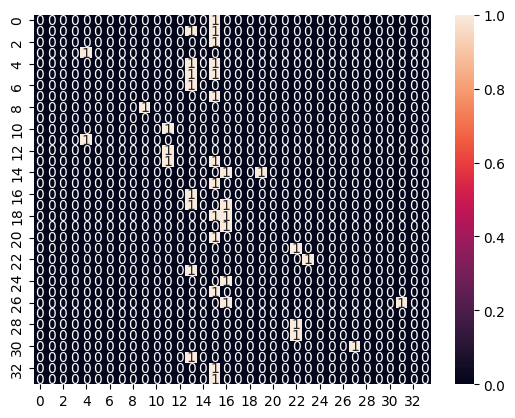

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(ytest,pred_lr)
sns.heatmap(cm,annot=True)

CORRECLATION PLOT

<function matplotlib.pyplot.show(close=None, block=None)>

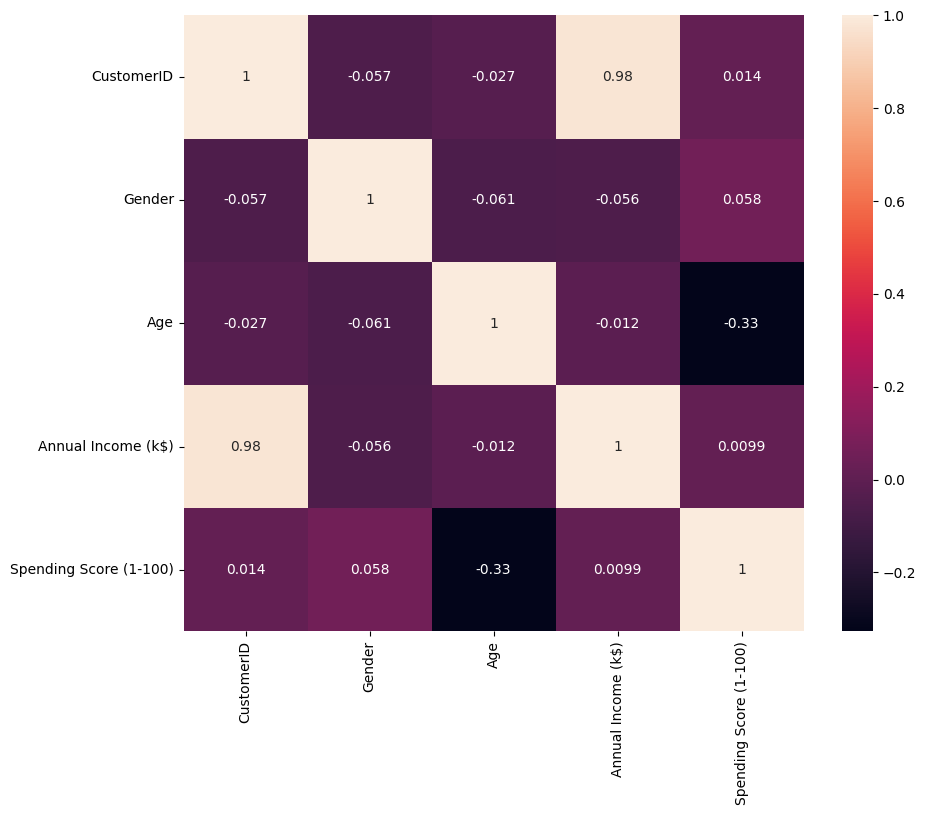

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = df.select_dtypes(include=['number']).columns
sns.heatmap(df.corr(),annot=True)
corr=df.corr()
corr.style.background_gradient(cmap='coolwarm')
fig=plt.gcf()
fig.set_size_inches(10,8)
plt.show

LOOK FOR OUTLIERS USING BOXPLOT

#HANDLING OUTLIERS

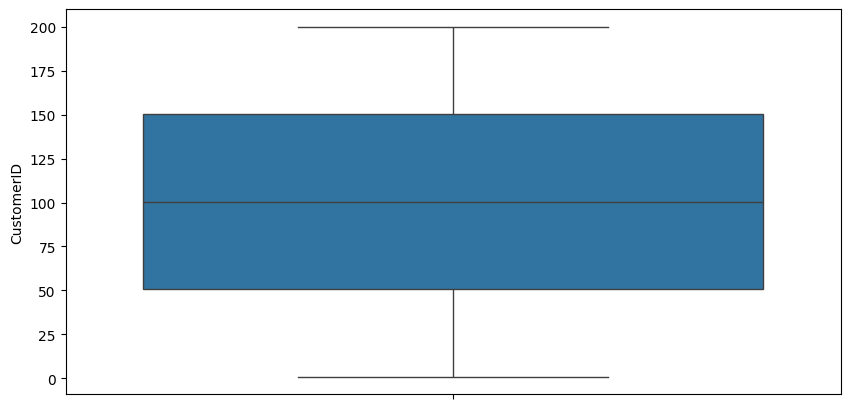

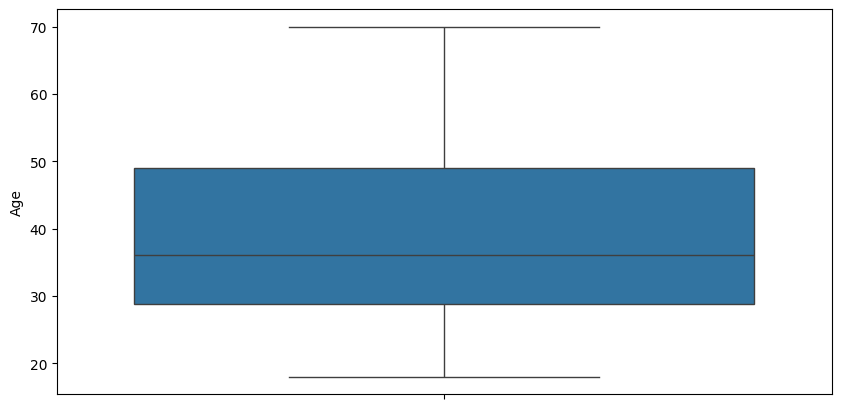

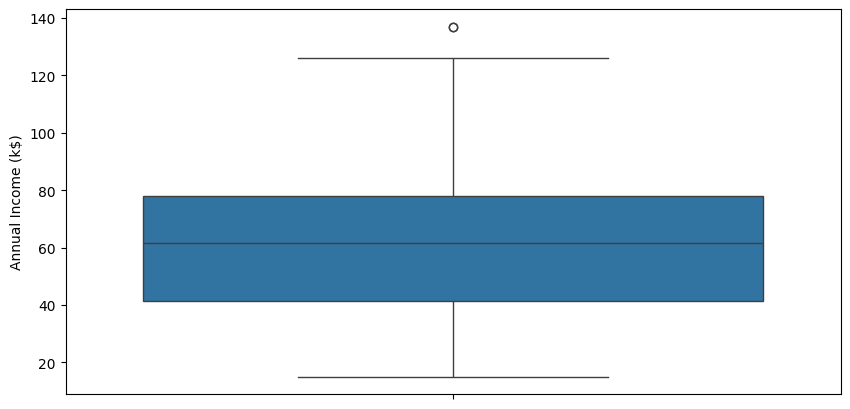

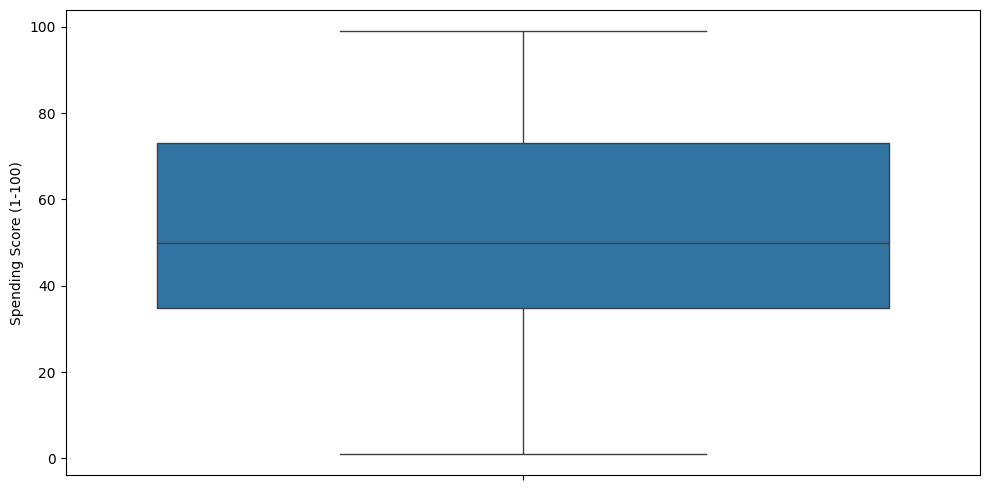

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df['CustomerID'])
plt.figure(figsize=(10,5))
sns.boxplot(data=df['Age'])
plt.figure(figsize=(10,5))
sns.boxplot(data=df['Annual Income (k$)'])
plt.figure(figsize=(10,5))
sns.boxplot(data=df['Spending Score (1-100)'])
plt.tight_layout()
plt.show()

CREATE A LINEAR REGRESSION MODEL

#LINEAR REGRESSION

In [ ]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(xtrain,ytrain)

LinearRegression()

#PREDICT THE MODEL



In [ ]:
pred_lr=LR.predict(xtest)

#ACCURACY SCORE

In [ ]:
LR.score(xtest,ytest)

0.1547323837582395

# PRINT THE REPORT
CLASSIFICATION,
ACCURACY
CONFUSION MATRIX

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pred_lr = LR.predict(xtest)

print('Mean Absolute Error:', mean_absolute_error(ytest, pred_lr))
print('Mean Squared Error:', mean_squared_error(ytest, pred_lr))
print('R-squared:', r2_score(ytest, pred_lr))

Mean Absolute Error: 10.907710465321268
Mean Squared Error: 175.38457769400287
R-squared: 0.1547323837582395


MODEL EVALUATION- OPTIONAL COMPARISM

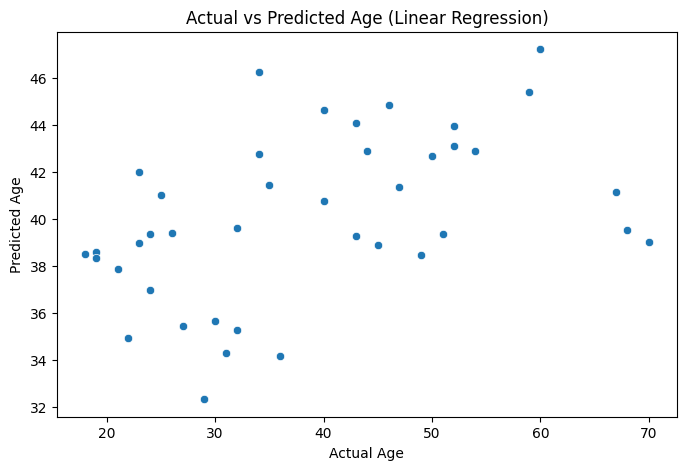

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.scatterplot(x=ytest.values.ravel(), y=pred_lr.ravel())
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Actual vs Predicted Age (Linear Regression)')
plt.show()

CLASSIFICATION OF MODELS IN LINEAR REGRESSION

In [ ]:
# Define models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
models = {
    "Simple Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
}

# Store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(xtrain, ytrain)
    ypred = model.predict(xtest)
    mse = mean_squared_error(ytest, ypred)
    r2 = r2_score(ytest, ypred)
    results[name] = {"MSE": mse, "R² Score": r2}

# Convert results to DataFrame and display
results_df = pd.DataFrame(results).T
print(results_df)

                                 MSE  R² Score
Simple Linear Regression  175.384578  0.154732
Ridge Regression          175.408125  0.154619
Lasso Regression          176.117235  0.151201


COMPARISON PLOT GRAPH

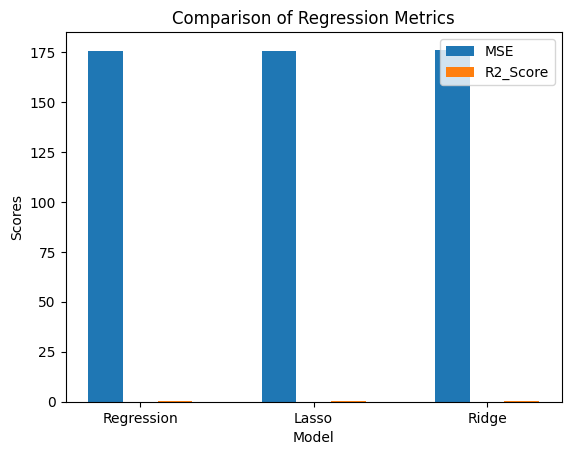

In [ ]:
# plot comparison
import matplotlib.pyplot as plt
import numpy as np

mse = results_df['MSE']
r2_score = results_df['R² Score']

positions = np.arange(len(mse))
bar_width = 0.2

plt.bar(positions - bar_width, mse, width = bar_width, label = 'MSE')
plt.bar(positions + bar_width, r2_score, width = bar_width, label = 'R2_Score')

# adding labels and title
plt.xlabel('Model')
plt.ylabel('Scores')
plt.title('Comparison of Regression Metrics')

# adding the legend
plt.legend()
plt.xticks(positions, ['Regression', 'Lasso', 'Ridge'])
plt.show()

APPLY TRAINING USING DECISON TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier()
DT.fit(xtrain,ytrain)

DecisionTreeClassifier()

#PREDICT THE MODEL

In [ ]:
pred_dt=DT.predict(xtest)

DECISION TREE SCORE

In [ ]:
DT.score(xtest,ytest)

0.0

CLASSIFICATION REPORT

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
pred_dt = DT.predict(xtest)
print(classification_report(ytest,pred_dt))
print(accuracy_score(ytest,pred_dt))
print(confusion_matrix(ytest,pred_dt))

              precision    recall  f1-score   support

          18       0.00      0.00      0.00       1.0
          19       0.00      0.00      0.00       2.0
          20       0.00      0.00      0.00       0.0
          21       0.00      0.00      0.00       1.0
          22       0.00      0.00      0.00       1.0
          23       0.00      0.00      0.00       2.0
          24       0.00      0.00      0.00       2.0
          25       0.00      0.00      0.00       1.0
          26       0.00      0.00      0.00       1.0
          27       0.00      0.00      0.00       1.0
          28       0.00      0.00      0.00       0.0
          29       0.00      0.00      0.00       1.0
          30       0.00      0.00      0.00       1.0
          31       0.00      0.00      0.00       1.0
          32       0.00      0.00      0.00       2.0
          34       0.00      0.00      0.00       2.0
          35       0.00      0.00      0.00       1.0
          36       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

GRADIENT BOOSTER MODEL

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
GB=GradientBoostingClassifier()
GB.fit(xtrain,ytrain.values.ravel())

GradientBoostingClassifier()

# PREDICT THE GRADIENT BOOSTER


In [ ]:
pred_gt=GB.predict(xtest)

GRADIENT SCORE

In [ ]:
GB.score(xtest,ytest)

0.0

CLASSIFICATION

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
pred_gt = GB.predict(xtest)
print(classification_report(ytest,pred_gt))
print(accuracy_score(ytest,pred_gt))
print(confusion_matrix(ytest,pred_gt))

              precision    recall  f1-score   support

          18       0.00      0.00      0.00       1.0
          19       0.00      0.00      0.00       2.0
          20       0.00      0.00      0.00       0.0
          21       0.00      0.00      0.00       1.0
          22       0.00      0.00      0.00       1.0
          23       0.00      0.00      0.00       2.0
          24       0.00      0.00      0.00       2.0
          25       0.00      0.00      0.00       1.0
          26       0.00      0.00      0.00       1.0
          27       0.00      0.00      0.00       1.0
          28       0.00      0.00      0.00       0.0
          29       0.00      0.00      0.00       1.0
          30       0.00      0.00      0.00       1.0
          31       0.00      0.00      0.00       1.0
          32       0.00      0.00      0.00       2.0
          34       0.00      0.00      0.00       2.0
          35       0.00      0.00      0.00       1.0
          36       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

SCATTERPLOT FOR GRADIENT BOOSTER

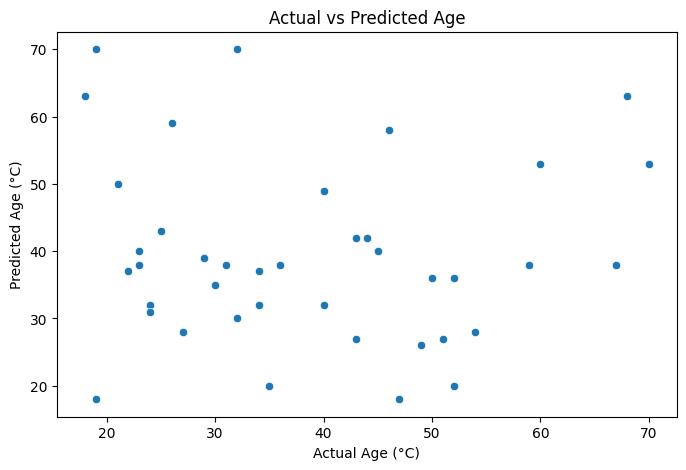

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=ytest.values.ravel(), y=pred_gt.ravel())
plt.xlabel('Actual Age (°C)')
plt.ylabel('Predicted Age (°C)')
plt.title('Actual vs Predicted Age')
plt.show()

RANDOM FOREST MODEL

In [ ]:
from sklearn.ensemble import RandomForestClassifier
RF=RandomForestClassifier()
RF.fit(xtrain,ytrain.values.ravel())

RandomForestClassifier()

# PREDICT THE MODEL USING THE MODEL

In [ ]:
pred_rf = RF.predict(xtest)

# ACCURACY SCORE

In [ ]:
RF.score(xtest,ytest)

0.0

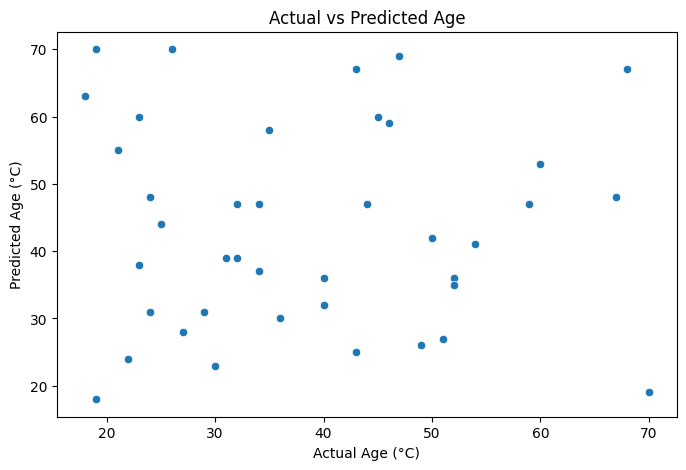

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=ytest.values.ravel(), y=pred_rf)
plt.xlabel('Actual Age (°C)')
plt.ylabel('Predicted Age (°C)')
plt.title('Actual vs Predicted Age')
plt.show()

FEATURE SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)

USE THE KMEANS CLUSTERING

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(x_scaled)
df['KMeans_Cluster'] = kmeans.labels_

TO VISUALISE THE DATA

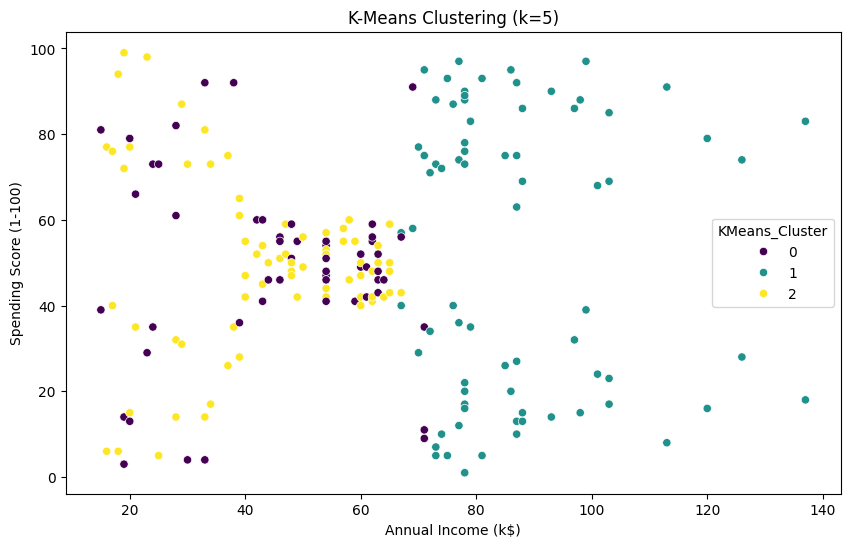

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_Cluster', data=df, palette='viridis')
plt.title('K-Means Clustering (k=5)')
plt.show()

HIERARCHICAL CLUSTERING

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agglo=AgglomerativeClustering(n_clusters=5)
df['Agglo_Cluster']=agglo.fit_predict(x_scaled)


VISUALIZING THE DATA

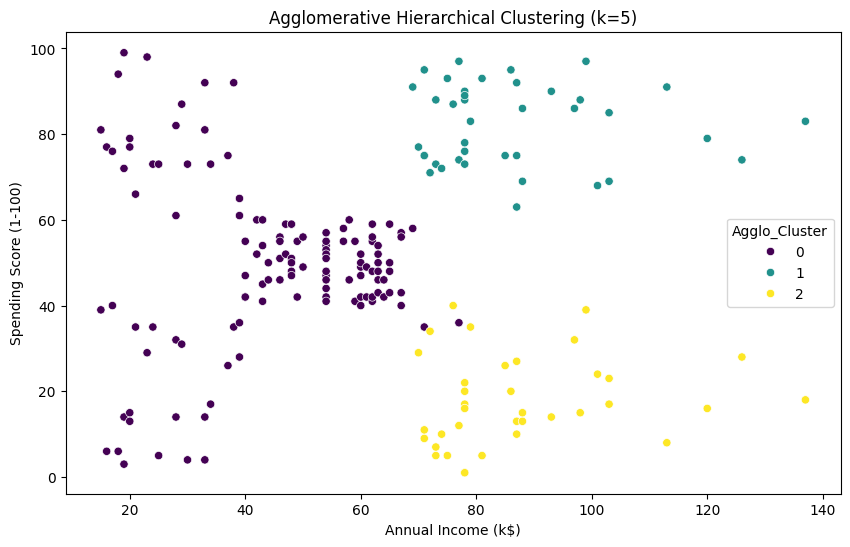

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Agglo_Cluster', data=df, palette='viridis')
plt.title('Agglomerative Hierarchical Clustering (k=5)')
plt.show()

USE THE DENDROGRAM HIERARCHICAL CLUSTERING

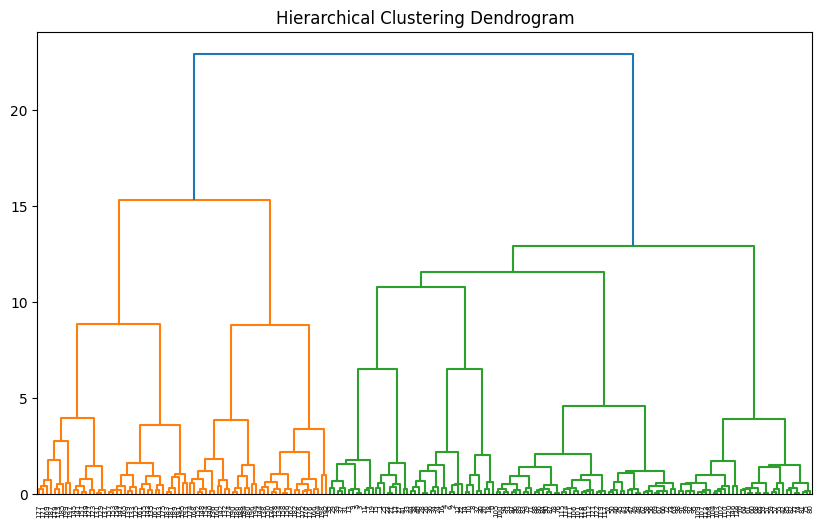

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(x_scaled, 'ward')
plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending',show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
#plt.xlabel('Sample Index')
#plt.ylabel('Distance')
plt.show()

DBSCAN MODEL

In [ ]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=0.5,min_samples=5)
df['DBSCAN_Cluster']=dbscan.fit_predict(x_scaled)

TO VISUALISE THE DATA

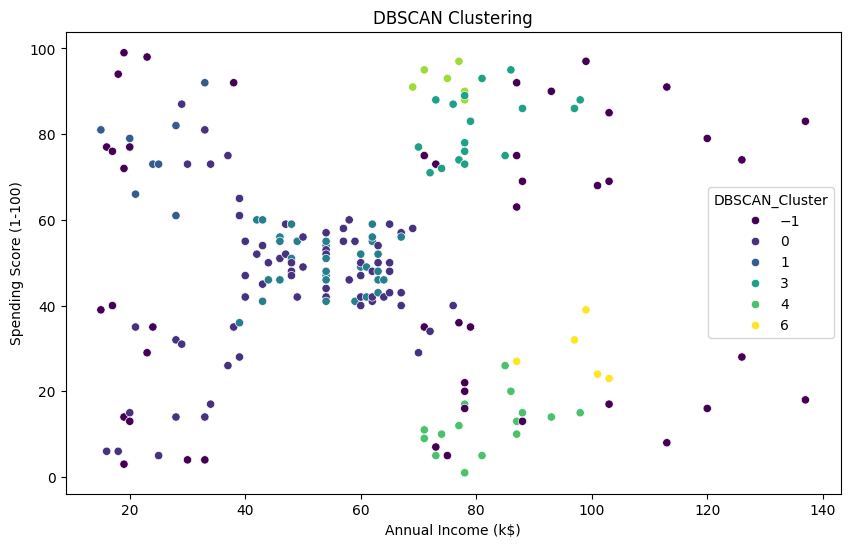

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', data=df, palette='viridis')
plt.title('DBSCAN Clustering')
plt.show()


EVALUATION - SILHOUETTE SCORE

In [ ]:
from sklearn.metrics import silhouette_score
print("\nK-Means Silhouette Score:", silhouette_score(x_scaled, kmeans.labels_))
print("Agglomerative Hierarchical Silhouette Score:", silhouette_score(x_scaled, agglo.labels_))
print("DBSCAN Silhouette Score:", silhouette_score(x_scaled, dbscan.labels_))


K-Means Silhouette Score: 0.3209841797040241
Agglomerative Hierarchical Silhouette Score: 0.3388595976409992
DBSCAN Silhouette Score: 0.27613525215111734


CALINSKI INDEX

In [ ]:
from sklearn.metrics import calinski_harabasz_score
print("\nK-means Calinski_Harabasz Index:",calinski_harabasz_score(x, kmeans.labels_))
print("Agglomerative Hierarchical Calinski_Harabasz Index:",calinski_harabasz_score(x, agglo.labels_))
print("DBSCAN Calinski_Harabasz Index:",calinski_harabasz_score(x_scaled, dbscan.labels_))


K-means Calinski_Harabasz Index: 142.46283804574117
Agglomerative Hierarchical Calinski_Harabasz Index: 212.09136000170238
DBSCAN Calinski_Harabasz Index: 26.715764281864672


VISAULIZE THE COMAPRISON OF THE SCORES

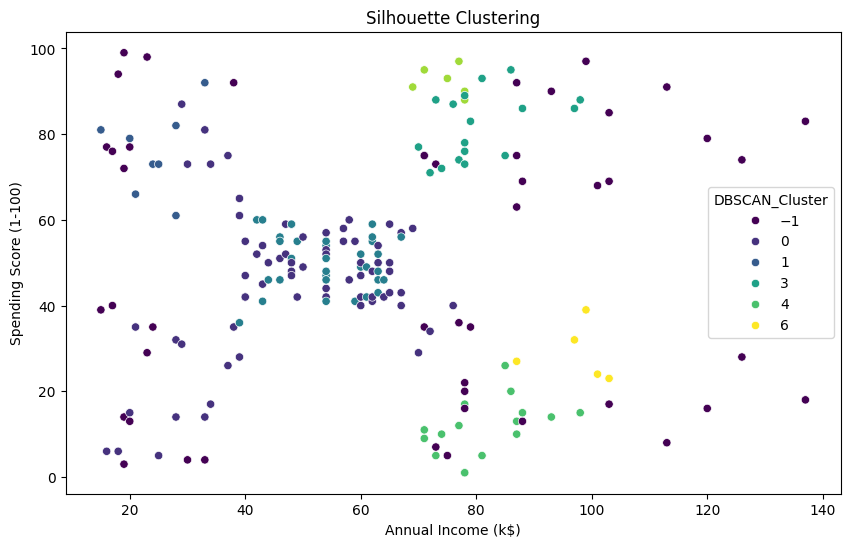

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', data=df, palette='viridis')
plt.title('Silhouette Clustering')
plt.show()